# Ejercicio 1

Implemente el algoritmo de retropropagación para un perceptrón multicapa,
de forma que se pueda elegir libremente la cantidad de capas de la red
y de neuronas en cada capa. Pruébelo entrenando una red de estructura apropiada
para resolver el problema XOR, con sus particiones de entrenamiento y
prueba correspondientes (datos de la Guía de trabajos prácticos 1).

Una estructura apropiada para este problema es optar por dos capas:
- Capa oculta con salida no lineal (como una sigmoide simetrica) con dos neuronas
- Capa de salida de una sola neurona con salida no lineal (con sigmoide simetrica)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.neural_network import neural_network
from algorithms.auxiliares import *

In [2]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'XOR_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'XOR_tst.csv'))

y_train, y_test = np.array(y_train), np.array(y_test)

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

model = neural_network(
    layers_config = [(2, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input = X_train.shape[1],
    max_epoch=100,
    learning_rate=0.01,
    error_threshold=1e-5)

model.fit(X_train, y_train)

y_pred = model.transform(X_test)

print(model.score(X_test, y_test))
print(model.confusion_matrix(X_test, y_test))

1.0
[[112.   0.]
 [  0.  88.]]


In [3]:
print(y_test.shape, y_pred.shape)
print(np.hstack((y_test, y_pred)))

(200, 1) (200, 1)
[[-1.         -0.9670463 ]
 [ 1.          0.97439757]
 [-1.         -0.96493953]
 [-1.         -0.9659283 ]
 [-1.         -0.96520462]
 [-1.         -0.96556325]
 [ 1.          0.97394062]
 [ 1.          0.97423277]
 [-1.         -0.96684724]
 [ 1.          0.97392257]
 [-1.         -0.96559251]
 [-1.         -0.96562454]
 [ 1.          0.97441322]
 [ 1.          0.9744045 ]
 [ 1.          0.97430743]
 [-1.         -0.9651644 ]
 [-1.         -0.96469571]
 [ 1.          0.97418287]
 [ 1.          0.97454141]
 [-1.         -0.9649472 ]
 [ 1.          0.97438216]
 [-1.         -0.96523801]
 [ 1.          0.97358443]
 [-1.         -0.96633001]
 [ 1.          0.97439334]
 [ 1.          0.97441349]
 [ 1.          0.97424971]
 [-1.         -0.96488504]
 [-1.         -0.96504293]
 [-1.         -0.96571789]
 [-1.         -0.96473376]
 [ 1.          0.97397527]
 [-1.         -0.96494373]
 [ 1.          0.97450349]
 [-1.         -0.96544928]
 [-1.         -0.96347389]
 [-1.     

Inspeccionando un poco como se comporta el modelo podemos ver la curva del error

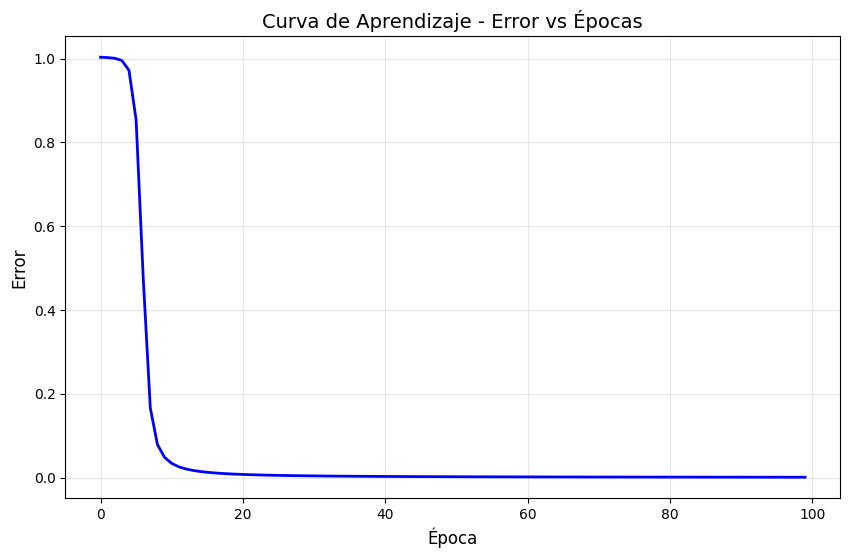

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Vamos a inspeccionar que superficie de decision se tiene

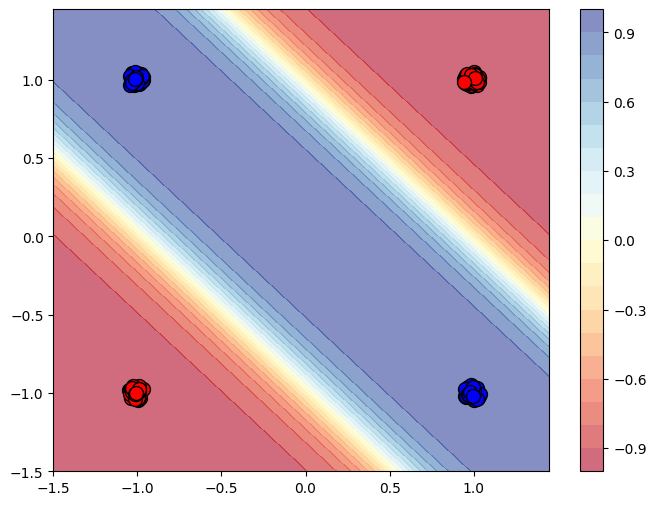

In [5]:
x_min, x_max = -1.5, 1.5
y_min, y_max = -1.5, 1.5

resolucion = 0.05 #delta x y delta y para hacer la maya

xx=np.arange(x_min, x_max, resolucion)
yy=np.arange(y_min, y_max, resolucion)

#creamos la malla 2d
X_malla, Y_malla = np.meshgrid(xx, yy)

#para cada punto de la malla predecimos su clase

puntos_aplanados = np.c_[X_malla.ravel(), Y_malla.ravel()] #los aplana para recorrerlos

predicciones = []
for punto in puntos_aplanados:
    punto_fila = punto.reshape(1,-1) #nuestra red espera una fila
    salida = model.transform(punto_fila)
    predicciones.append(salida.flatten()[0]) #retorna array nuestra salida

#convertimos a una malla
Z = np.array(predicciones).reshape(X_malla.shape)

plt.figure(figsize=(8, 6))
cont = plt.contourf(X_malla, Y_malla, Z, levels=20, cmap='RdYlBu', alpha=0.6)
plt.colorbar(cont)
for i in range(len(X_test)):
    if y_test[i] == 1:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='blue', s=100, edgecolors='black')
    else:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='red', s=100, edgecolors='black')


